# Jupyter - Day 10 - Section 001
# Lec 10: Logistic Regression

In [1]:
import numpy as np 
import matplotlib.pyplot as plt
import pandas as pd 
%matplotlib inline
import seaborn as sns

# Getting a feel for the data

We're going to use the `Default` data set from the ISLR book as included in their R package.  I've included a csv on the [DataSets page](../../DataSets/DataSets.md) for you to use. 

In [2]:
url = "https://msu-cmse-courses.github.io/CMSE381-S26/_downloads/0bf0b0b65f603971cd33a04ad934449c/Default.csv"
Default = pd.read_csv(url)
Default.head()

,default,student,balance,income
0,No,No,729.526495,44361.62507
1,No,Yes,817.180407,12106.13470
2,No,No,1073.549164,31767.13895
3,No,No,529.250605,35704.49394
4,No,No,785.655883,38463.49588


In [4]:
# Here's all the entries in the "default" column
list(Default['default'].unique())

['No', 'Yes']

## Classification using Logistic Regression

Our goal is to predict `default`, a categorical variable taking as values the strings `No` and `Yes`.


For this module, we will largely use the tools from `sklearn`  for classification. One of the big perks of the `sklearn` module is that there is a great deal of uniformity in the classes. So once we have a handle on how to interact with one kind of classification tool, very minor tweaks in the code will allow for the use of a new model. In fact, many of the things we'll do today should look very similar in terms of the syntax to the linear regression lab from a few weeks ago. 

For our first try doing classification, we'll use `LogisticRegression` from the `sklearn.linear_model` module. I'm a huge fan of the `sklean` documentaiton since it includes a great deal of info on the math behind what we're doing as well as explanations on the code:
- [`sklearn` mathematical description of logistic regression](https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression)
- [`LogisticRegression` class documentation](https://scikit-learn.org/stable/modules/generated/sklearn.linear_model.LogisticRegression.html#sklearn.linear_model.LogisticRegression)

In [5]:
from sklearn.linear_model import LogisticRegression 

Lets first predict `default` using `balance`. 
Our first job is to extract the portion of the dataframe that we want to use. 

In [6]:
X = Default[['balance']] 
Y = Default['default']

In [7]:
print(X.shape)
print(Y.shape)

(10000, 1)
(10000,)


Once we have our data, we create an instance of the model class we want, in this case `LogisticRegression`, and fit the model to the data. Note the `random_state=0` code ensures that rerunning the following box will return the same answer every time. 

In [8]:
clf = LogisticRegression(random_state=0)
clf.fit(X,Y)


,"penalty penalty: {'l1', 'l2', 'elasticnet', None}, default='l2'Specify the norm of the penalty:- `None`: no penalty is added;- `'l2'`: add a L2 penalty term and it is the default choice;- `'l1'`: add a L1 penalty term;- `'elasticnet'`: both L1 and L2 penalty terms are added... warning:: Some penalties may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionadded:: 0.19 l1 penalty with SAGA solver (allowing 'multinomial' + L1).. deprecated:: 1.8 `penalty` was deprecated in version 1.8 and will be removed in 1.10. Use `l1_ratio` instead. `l1_ratio=0` for `penalty='l2'`, `l1_ratio=1` for `penalty='l1'` and `l1_ratio` set to any float between 0 and 1 for `'penalty='elasticnet'`.",'deprecated'
,"C C: float, default=1.0Inverse of regularization strength; must be a positive float.Like in support vector machines, smaller values specify strongerregularization. `C=np.inf` results in unpenalized logistic regression.For a visual example on the effect of tuning the `C` parameterwith an L1 penalty, see::ref:`sphx_glr_auto_examples_linear_model_plot_logistic_path.py`.",1.0
,"l1_ratio l1_ratio: float, default=0.0The Elastic-Net mixing parameter, with `0 <= l1_ratio <= 1`. Setting`l1_ratio=1` gives a pure L1-penalty, setting `l1_ratio=0` a pure L2-penalty.Any value between 0 and 1 gives an Elastic-Net penalty of the form`l1_ratio * L1 + (1 - l1_ratio) * L2`... warning:: Certain values of `l1_ratio`, i.e. some penalties, may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionchanged:: 1.8 Default value changed from None to 0.0... deprecated:: 1.8 `None` is deprecated and will be removed in version 1.10. Always use `l1_ratio` to specify the penalty type.",0.0
,"dual dual: bool, default=FalseDual (constrained) or primal (regularized, see also:ref:`this equation `) formulation. Dual formulationis only implemented for l2 penalty with liblinear solver. Prefer `dual=False`when n_samples > n_features.",False
,"tol tol: float, default=1e-4Tolerance for stopping criteria.",0.0001
,"fit_intercept fit_intercept: bool, default=TrueSpecifies if a constant (a.k.a. bias or intercept) should beadded to the decision function.",True
,"intercept_scaling intercept_scaling: float, default=1Useful only when the solver `liblinear` is usedand `self.fit_intercept` is set to `True`. In this case, `x` becomes`[x, self.intercept_scaling]`,i.e. a ""synthetic"" feature with constant value equal to`intercept_scaling` is appended to the instance vector.The intercept becomes``intercept_scaling * synthetic_feature_weight``... note:: The synthetic feature weight is subject to L1 or L2 regularization as all other features. To lessen the effect of regularization on synthetic feature weight (and therefore on the intercept) `intercept_scaling` has to be increased.",1
,"class_weight class_weight: dict or 'balanced', default=NoneWeights associated with classes in the form ``{class_label: weight}``.If not given, all classes are supposed to have weight one.The ""balanced"" mode uses the values of y to automatically adjustweights inversely proportional to class frequencies in the input dataas ``n_samples / (n_classes * np.bincount(y))``.Note that these weights will be multiplied with sample_weight (passedthrough the fit method) if sample_weight is specified... versionadded:: 0.17 *class_weight='balanced'*",None
,"random_state random_state: int, RandomState instance, default=NoneUsed when ``solver`` == 'sag', 'saga' or 'liblinear' to shuffle thedata. See :term:`Glossary ` for details.",0
,"solver solver: {'lbfgs', 'liblinear', 'newton-cg', 'newton-cholesky', 'sag', 'saga'}, default='lbfgs'Algorithm to use in the optimization problem. Default is 'lbfgs'.To choose a solver, you might want to consider the following aspects:- 'lbfgs' is a good default solver because it works reasonably well for a wide class of problems.- For :term:`multic

One thing that is helpful for later is the `.classes_` variable which stores the possible values of $Y$ being predicted. Take note of the order of these things, it will matter later!

In [9]:
clf.classes_

array(['No', 'Yes'], dtype=object)

Great, that was easy! Once we've fit the model, the main task is to understand how to extract information from it. 

&#9989; **<font color=red>Do this:</font>** Extract the coefficients and intercept from the trained model.  
- What is the equation, in terms of the variables used, that you are modeling?


*(Hint: You might need to take a look at the documentation to figure out how get the coefficients and intercepts, but you should notice that `sklearn` has a pattern as to how it does this.)*

In [13]:
coef = clf.coef_
intercept = clf.intercept_

print("Coefficient:", coef)
print("Intercept:", intercept)

# log(P(Yes)/P(No)) = -10.6513 + 0.0054989 * balance

Coefficient: [[0.00549892]]
Intercept: [-10.65132824]


&#9989; **<font color=red>Do this:</font>** Extract the coefficients and intercept from the trained model.  
- Be specific about what probability you are modeling! 

###YOUR ANSWER HERE###

Modeling the log-odds that a customer defaults as a linear function of their credit card balance. The fitted model shows that higher balances substantially increase the probability of default. This model estimates the probability that a customer defaults, given their credit card balance. The positive coefficient on balance indicates that higher balances are associated with a higher probability of default.

While it's good to know what equation we're modeling with, the big perk here is that your `sklearn` class will evaluate the data points of your model for you. Yay!

&#9989; **<font color=red>Do this:</font>** Use the `predict_proba` function to determine the probabilities $Pr(Y = \texttt{Down} \mid X)$ for the data set. What shape is the output matrix? Why that shape? What do the columns represent?

In [14]:
# Checking up on the order of classes 

clf.classes_

array(['No', 'Yes'], dtype=object)

In [17]:
probs = clf.predict_proba(X)

print(probs.shape)
probs[:5]

# 10000 by 2 matrix because the model computes a probability for each
# of the two possible classes for evry observation. Columns correspond to
# class labels in clf.classes, second column representing the modeled
# probability that an observation defaults.

(10000, 2)


array([[9.98694319e-01, 1.30568146e-03],
       [9.97887402e-01, 2.11259754e-03],
       [9.91405252e-01, 8.59474814e-03],
       [9.99565562e-01, 4.34437534e-04],
       [9.98223040e-01, 1.77695967e-03]])

Of course this gives us the probability of each each label for a given data, but we really would like to have the prediction itself. 


&#9989; **<font color=red>Do this:</font>** (a). Use the `predict` function to determine the predictions for each input data point in the original $X$ matrix and store the output as `Yhat`. How many predictions are different than the actual `Direction` value? Whats the percent error for the model?

In [19]:
# Your code here

Yhat = clf.predict(X)
num_errors = (Yhat != Y).sum()
percent_error = num_errors / len(Y) * 100

print("Number of errors:", num_errors)
print("Percent error:", percent_error)

# Using predict, class predictions Yhat for all 10,000 observations.
# Number of incorrect predictions: 275
# Percent error: 2.75%

Number of errors: 275
Percent error: 2.75



&#9989; **<font color=red>Do this:</font>** (b). How many predictions are different than the actual `Direction` value? Whats the percent error for the model?

In [20]:
###YOUR ANSWER HERE###

# Number of incorrect predictions: 275
# Percent error: 2.75%


&#9989; **<font color=red>Do this:</font>** An even easier way of figuring out the error rate is through the score. What does the output of `clf.score(X,Y)` mean and how is it related to the number you determined above?

In [21]:
# Your code here

score = clf.score(X, Y)
percent_error = (1 - score) * 100
print("Accuracy:", score)
print("Percent error:", percent_error)

Accuracy: 0.9725
Percent error: 2.749999999999997


**Confusion matrix**

As we saw in class, the percent error is a rather limited way of evaluating the classification model. Luckily `sklearn` provides commands for computing the confusion matrix for a given model easily. The `confusion_matrix` command computes the confusion matrix, and `ConfusionMatrixDisplay` gives a nice visual representation. 

In [22]:
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay


In [23]:
# This code gives the confusion matrix, assuming you stored the predicted values as `Yhat`.
C = confusion_matrix(Y,Yhat)

C

array([[9625,   42],
       [ 233,  100]])

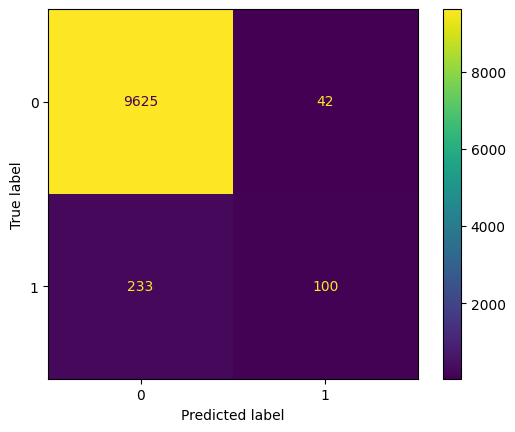

In [24]:
# This code gives a visual representation 
ConfusionMatrixDisplay(C).plot()



&#9989; **<font color=red>Q:</font>** The makers of `sklearn` made a strange choice when it comes to the confusion matrix representation.  What is different about the `sklearn` confusion matrix from how we saw it in class?

*Rows correspond to the true labels. Columns correspond to the predicted labels*



-----
### Congratulations, we're done!
Initially created by Dr. Liz Munch, modified by Dr. Lianzhang Bao and Dr. Firas Khasawneh, Michigan State University

<a rel="license" href="http://creativecommons.org/licenses/by-nc/4.0/"><img alt="Creative Commons License" style="border-width:0" src="https://i.creativecommons.org/l/by-nc/4.0/88x31.png" /></a><br />This work is licensed under a <a rel="license" href="http://creativecommons.org/licenses/by-nc/4.0/">Creative Commons Attribution-NonCommercial 4.0 International License</a>.